In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)


In [5]:

# ============================================================
# CONFIG
# ============================================================
MODEL_NAME = "mlp"
BASE_NAMES = [
    "fraud_prepared_numeric",
    "fraud_selected_features_rfecv",
    "fraud_pca_95_variance"
]

OUT_DIR = Path("../model/MLP/figure")
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_DIR = Path.cwd()
CSV_DIR = (BASE_DIR / ".." / "model" / MODEL_NAME.upper() / "csv").resolve()

RESULTS_FILE = CSV_DIR/f"{MODEL_NAME}_results_comparison.csv"


In [6]:

# ============================================================
# Helper functions
# ============================================================
def pretty_dataset_name(base_name):
    mapping = {
        "fraud_prepared_numeric": "Prepared Numeric Dataset",
        "fraud_selected_features_rfecv": "Feature-Selected Dataset (RFECV)",
        "fraud_pca_95_variance": "PCA Dataset (95% Variance)"
    }
    return mapping.get(base_name, base_name)

def load_history(base_name):
    path = CSV_DIR / f"{base_name}_{MODEL_NAME}_history.csv"
    if os.path.exists(path):
        return pd.read_csv(path)
    return None

def load_predictions(base_name):
    path = CSV_DIR / f"{base_name}_{MODEL_NAME}_test_predictions.csv"
    if os.path.exists(path):
        return pd.read_csv(path)
    return None


In [7]:

def plot_metric_comparison(results_df):
    metrics_to_plot = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

    x = np.arange(len(results_df))
    width = 0.12

    plt.figure(figsize=(14, 6))
    for i, metric in enumerate(metrics_to_plot):
        plt.bar(x + i * width, results_df[metric], width=width, label=metric)

    plt.xticks(x + width * (len(metrics_to_plot) - 1) / 2, results_df["dataset_label"], rotation=15)
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title("MLP Performance Comparison Across 3 Datasets")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR/"mlp_metrics_comparison.png", dpi=300)
    plt.show()

def plot_history_curves(base_name, history_df):
    dataset_label = pretty_dataset_name(base_name)

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"MLP Loss Curve - {dataset_label}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR/f"{base_name}_mlp_loss_curve.png", dpi=300)
    plt.show()

    # PR AUC
    if "pr_auc" in history_df.columns and "val_pr_auc" in history_df.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(history_df["pr_auc"], label="Train PR AUC")
        plt.plot(history_df["val_pr_auc"], label="Validation PR AUC")
        plt.xlabel("Epoch")
        plt.ylabel("PR AUC")
        plt.title(f"MLP PR AUC Curve - {dataset_label}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT_DIR/f"{base_name}_mlp_pr_auc_curve.png", dpi=300)
        plt.show()

def plot_conf_matrix(base_name, pred_df):
    dataset_label = pretty_dataset_name(base_name)

    y_true = pred_df["y_true"]
    y_pred = pred_df["y_pred"]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
    plt.title(f"MLP Confusion Matrix - {dataset_label}")
    plt.tight_layout()
    plt.savefig(OUT_DIR/f"{base_name}_mlp_confusion_matrix.png", dpi=300)
    plt.show()

def plot_roc_all(base_names):
    plt.figure(figsize=(8, 6))

    for base_name in base_names:
        pred_df = load_predictions(base_name)
        if pred_df is None:
            continue

        y_true = pred_df["y_true"]
        y_prob = pred_df["y_prob"]

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc_value = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{pretty_dataset_name(base_name)} (AUC={roc_auc_value:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("MLP ROC Curves Across 3 Datasets")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR/"mlp_roc_curves_all_datasets.png", dpi=300)
    plt.show()

def plot_pr_all(base_names):
    plt.figure(figsize=(8, 6))

    for base_name in base_names:
        pred_df = load_predictions(base_name)
        if pred_df is None:
            continue

        y_true = pred_df["y_true"]
        y_prob = pred_df["y_prob"]

        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        pr_auc_value = auc(recall, precision)

        plt.plot(recall, precision, label=f"{pretty_dataset_name(base_name)} (AUC={pr_auc_value:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("MLP Precision-Recall Curves Across 3 Datasets")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR/"mlp_pr_curves_all_datasets.png", dpi=300)
    plt.show()


In [8]:

def print_text_analysis(results_df):
    print("=" * 90)
    print("MLP NUMERICAL ANALYSIS")
    print("=" * 90)

    best_pr_auc_row = results_df.loc[results_df["pr_auc"].idxmax()]
    best_f1_row = results_df.loc[results_df["f1"].idxmax()]
    best_recall_row = results_df.loc[results_df["recall"].idxmax()]
    best_accuracy_row = results_df.loc[results_df["accuracy"].idxmax()]

    print(f"Best dataset by PR AUC   : {best_pr_auc_row['dataset_label']} ({best_pr_auc_row['pr_auc']:.4f})")
    print(f"Best dataset by F1-score : {best_f1_row['dataset_label']} ({best_f1_row['f1']:.4f})")
    print(f"Best dataset by Recall   : {best_recall_row['dataset_label']} ({best_recall_row['recall']:.4f})")
    print(f"Best dataset by Accuracy : {best_accuracy_row['dataset_label']} ({best_accuracy_row['accuracy']:.4f})")
    print()

    for _, row in results_df.iterrows():
        base_name = row["dataset_base"]
        pred_df = load_predictions(base_name)
        if pred_df is None:
            continue

        y_true = pred_df["y_true"]
        y_pred = pred_df["y_pred"]
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

        print(f"Dataset: {row['dataset_label']}")
        print(f"  Accuracy    : {row['accuracy']:.4f}")
        print(f"  Precision   : {row['precision']:.4f}")
        print(f"  Recall      : {row['recall']:.4f}")
        print(f"  F1-score    : {row['f1']:.4f}")
        print(f"  ROC AUC     : {row['roc_auc']:.4f}")
        print(f"  PR AUC      : {row['pr_auc']:.4f}")
        print(f"  Threshold   : {row['best_threshold']:.2f}")
        print(f"  Conf Matrix : TN={tn}, FP={fp}, FN={fn}, TP={tp}")
        print(f"  Specificity : {specificity:.4f}")
        print(f"  FNR         : {false_negative_rate:.4f}")
        print()


                   dataset_label  n_features  best_threshold  accuracy  precision   recall       f1  roc_auc   pr_auc
        Prepared Numeric Dataset          55            0.65  0.923499   0.045243 0.119458 0.065629 0.610418 0.034310
Feature-Selected Dataset (RFECV)          17            0.50  0.664525   0.025370 0.371921 0.047499 0.534657 0.025336
      PCA Dataset (95% Variance)          11            0.50  0.549025   0.023883 0.477833 0.045492 0.523221 0.025045


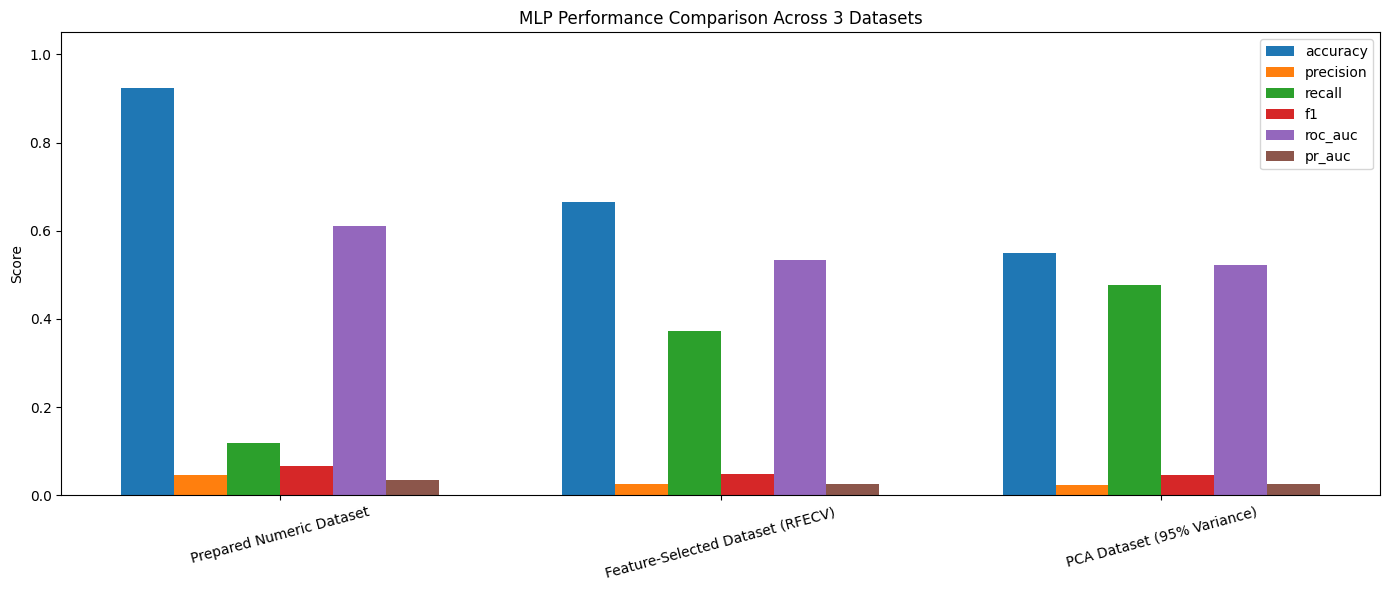

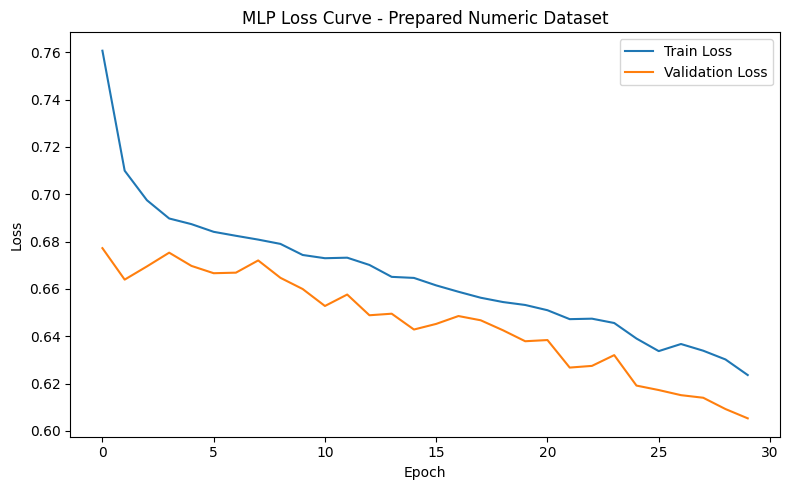

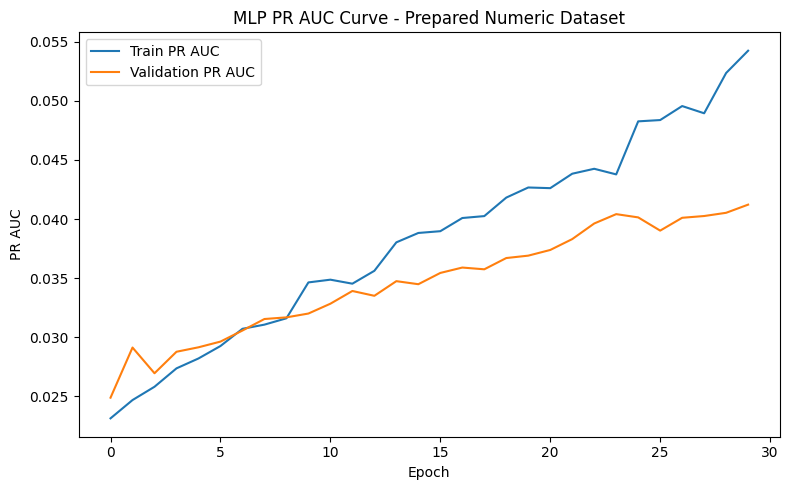

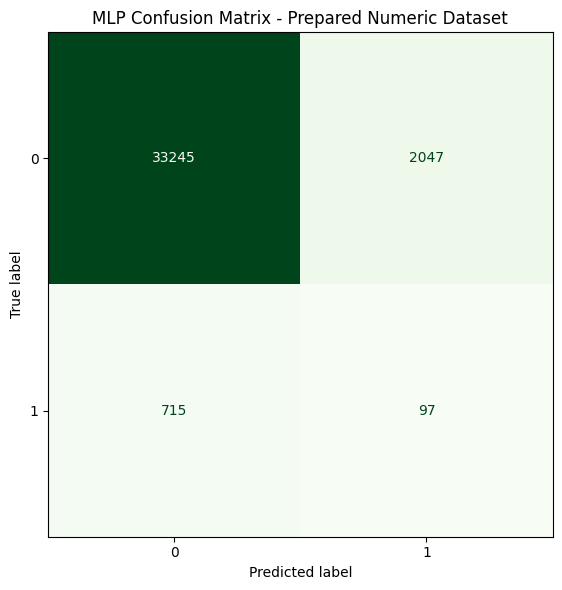

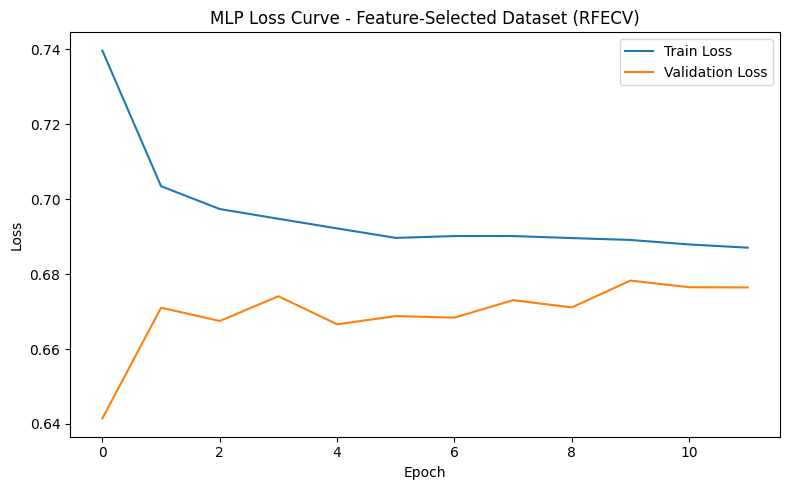

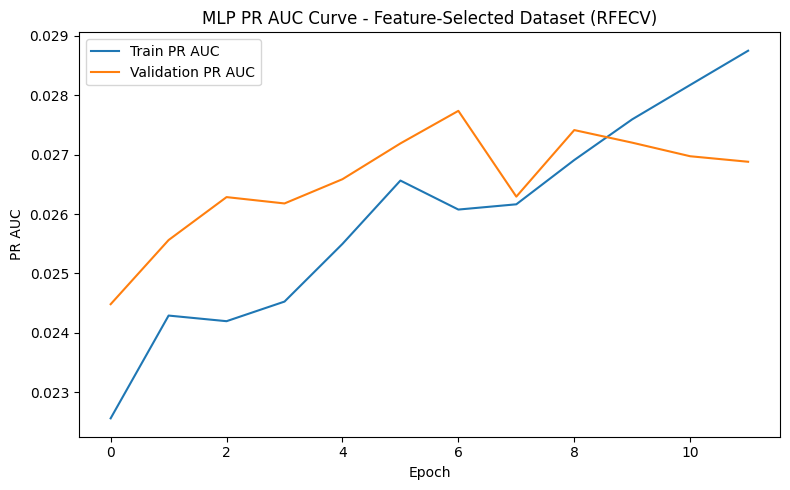

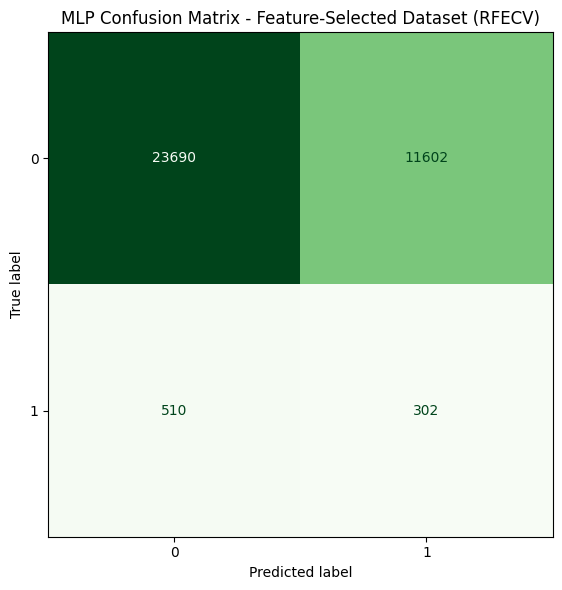

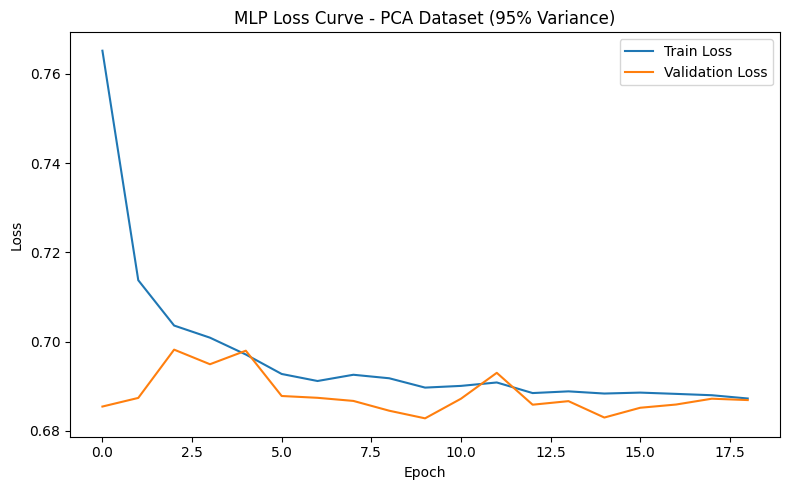

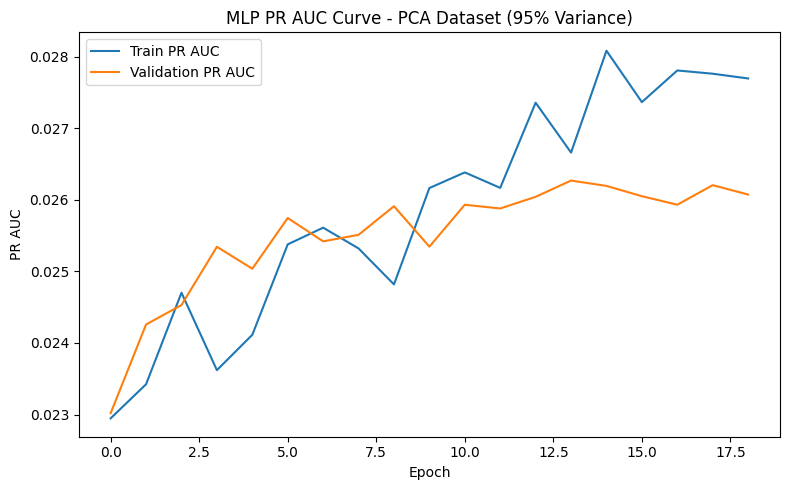

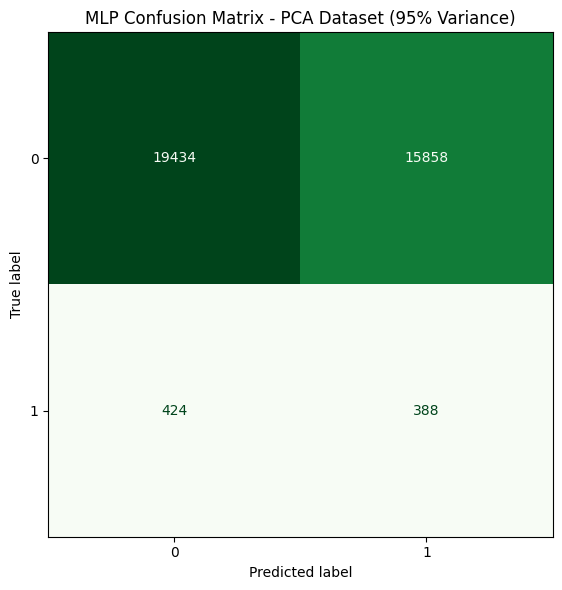

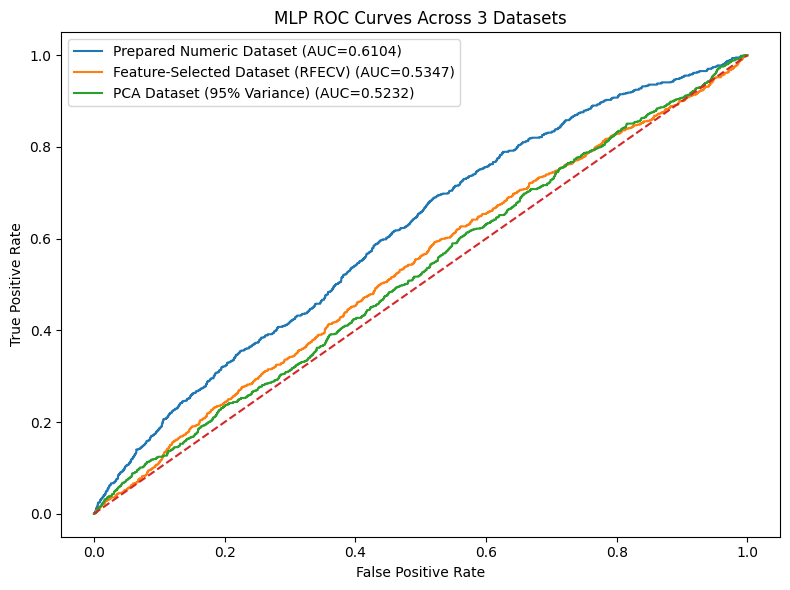

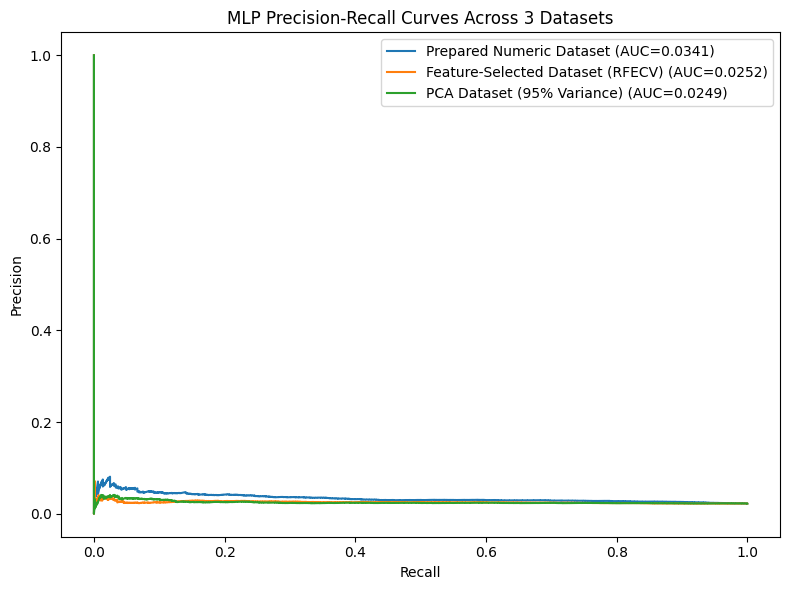

MLP NUMERICAL ANALYSIS
Best dataset by PR AUC   : Prepared Numeric Dataset (0.0343)
Best dataset by F1-score : Prepared Numeric Dataset (0.0656)
Best dataset by Recall   : PCA Dataset (95% Variance) (0.4778)
Best dataset by Accuracy : Prepared Numeric Dataset (0.9235)

Dataset: Prepared Numeric Dataset
  Accuracy    : 0.9235
  Precision   : 0.0452
  Recall      : 0.1195
  F1-score    : 0.0656
  ROC AUC     : 0.6104
  PR AUC      : 0.0343
  Threshold   : 0.65
  Conf Matrix : TN=33245, FP=2047, FN=715, TP=97
  Specificity : 0.9420
  FNR         : 0.8805

Dataset: Feature-Selected Dataset (RFECV)
  Accuracy    : 0.6645
  Precision   : 0.0254
  Recall      : 0.3719
  F1-score    : 0.0475
  ROC AUC     : 0.5347
  PR AUC      : 0.0253
  Threshold   : 0.50
  Conf Matrix : TN=23690, FP=11602, FN=510, TP=302
  Specificity : 0.6713
  FNR         : 0.6281

Dataset: PCA Dataset (95% Variance)
  Accuracy    : 0.5490
  Precision   : 0.0239
  Recall      : 0.4778
  F1-score    : 0.0455
  ROC AUC     

In [9]:

# ============================================================
# MAIN
# ============================================================
if not os.path.exists(RESULTS_FILE):
    raise FileNotFoundError(f"{RESULTS_FILE} not found. Run MLP training first.")

results_df = pd.read_csv(RESULTS_FILE)

results_df["dataset_base"] = results_df["dataset"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
results_df["dataset_label"] = results_df["dataset_base"].apply(pretty_dataset_name)

print(results_df[[
    "dataset_label", "n_features", "best_threshold",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
]].to_string(index=False))

# 1) Comparison graph
plot_metric_comparison(results_df)

# 2) Training history + confusion matrix for each dataset
for base_name in BASE_NAMES:
    history_df = load_history(base_name)
    pred_df = load_predictions(base_name)

    if history_df is not None:
        plot_history_curves(base_name, history_df)

    if pred_df is not None:
        plot_conf_matrix(base_name, pred_df)

# 3) ROC and PR curves
plot_roc_all(BASE_NAMES)
plot_pr_all(BASE_NAMES)

# 4) Print summary analysis
print_text_analysis(results_df)